In [1]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator


import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from OptimumFilter import *

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
ts = LongTraceSimulator(config)

def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/home/dwong/software/TraceSimulator/TraceSimulator/LongTraceSimulator.py:205: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


In [11]:
trace = ts.generate(
            E=300,
            x=0, y=0, z=-1700,
            no_noise=True,
            type_recoil='NR',
            quantize=False,
            phonon_only=True,
        )

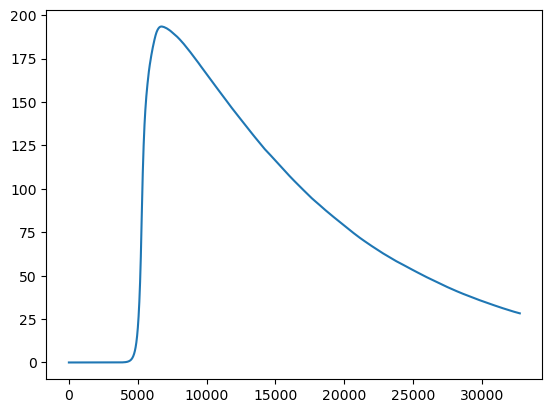

In [15]:
plt.plot(trace[0][37][25000:32768+25000])

Note: couldn't register in vac_of: name 'vac_of' is not defined


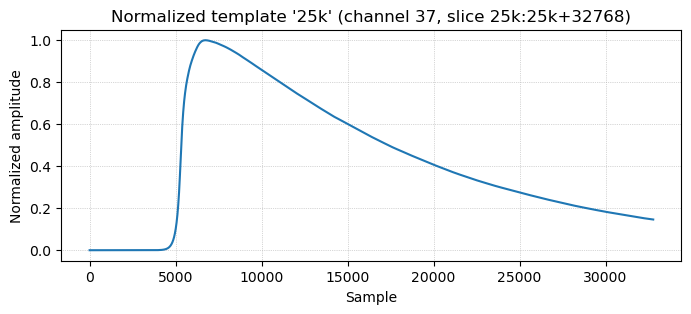

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- slice, baseline, normalize ---
start = 25000
length = 32768
ch = 37

seg = np.array(trace[0][ch][start:start+length], dtype=float)

# Baseline from the first 2000 samples of the slice (adjust if you prefer)
baseline = np.median(seg[:2000])
seg_bs = seg - baseline

# Normalize so the absolute peak becomes +1
peak_idx = int(np.argmax(np.abs(seg_bs)))
peak_val = seg_bs[peak_idx]            # could be positive or negative
template_25k = seg_bs / peak_val       # dividing by peak sets that sample to +1

# --- save to disk and into a template bank ---
np.save("template_25k.npy", template_25k)

# In-memory registry (simple dict)
templates = {}
templates["25k"] = template_25k



# --- quick visual check (optional) ---
plt.figure(figsize=(8,3))
plt.plot(template_25k)
plt.title("Normalized template '25k' (channel 37, slice 25k:25k+32768)")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()


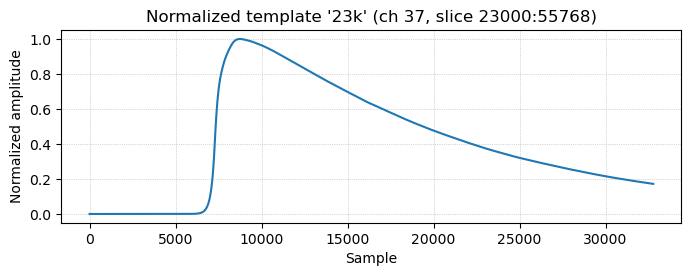

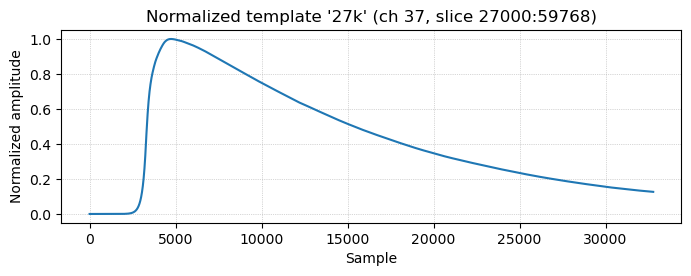

In [17]:
# Build 23k and 27k templates with the same normalization
for start in (23000, 27000):
    seg = np.array(trace[0][ch][start:start+length], dtype=float)
    baseline = np.median(seg[:2000])
    seg_bs = seg - baseline

    peak_idx = int(np.argmax(np.abs(seg_bs)))
    peak_val = seg_bs[peak_idx] if seg_bs[peak_idx] != 0 else 1.0  # avoid divide-by-zero

    template = seg_bs / peak_val  # same signed-peak normalization as your 25k code

    key = f"{start//1000}k"
    templates[key] = template
    np.save(f"template_{key}.npy", template)

    # optional quick look
    plt.figure(figsize=(8, 2.5))
    plt.plot(template)
    plt.title(f"Normalized template '{key}' (ch {ch}, slice {start}:{start+length})")
    plt.xlabel("Sample")
    plt.ylabel("Normalized amplitude")
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.show()
